# CARLOS FERNANDO GALÁN PACHÓN

## Bibliotecas y dataset

In [2]:
import pandas as pd
import numpy as np
import hdbscan
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import sqlite3
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')
import folium
from folium.plugins import HeatMap, MarkerCluster

In [4]:
r = r"C:\Users\qluis\Documents\Concejo\Bases de datos\Carlos Fernando Galan\historico_carlos_fernando_galan.csv"
df = pd.read_csv(r)
df.head()

,año,corporacion,lugar,votacion,localidad,longitud,latitud,geometry,upz
0,2007,CONCEJO,PUESTO CENSO(FERIA EXPOSICION),1904,NACIONAL,-74.089940,4.630370,POINT (-74.08994026099998 4.630369649000045),QUINTA PAREDES
1,2007,CONCEJO,ALTOS DE SAN ISIDRO,19,USAQUEN,-74.024490,4.669677,POINT (-74.0244897 4.6696769),SAN ISIDRO - PATIOS
2,2007,CONCEJO,BARRANCAS,143,USAQUEN,-74.026924,4.735220,POINT (-74.0269239 4.7352201),SAN CRISTOBAL NORTE
3,2007,CONCEJO,BUENAVISTA,7,USAQUEN,-74.025792,4.766857,POINT (-74.02579167099998 4.766856689000065),VERBENAL
4,2007,CONCEJO,CANAIMA,14,USAQUEN,-74.040988,4.772747,POINT (-74.04098847999995 4.772747019000064),PASEO DE LOS LIBERTADORES


## Análisis exploratorio espacial

BLOQUE 1: ANÁLISIS EXPLORATORIO ESPACIAL

1. Cargando shapefile UPZ...
   ✓ UPZ cargadas: 114 polígonos

2. Verificando estructura de datos...
   Registros en df: 3179
   UPZ asignadas: 3105 (74 sin UPZ)
   Rango de años: 2007 - 2023

3. Análisis estadístico por UPZ...
   • UPZ con datos: 108
   • UPZ sin datos: 6
   • Votos totales: 2,897,498
   • Puestos totales: 3,114

   TOP 10 UPZ POR VOTOS:
   66. BOSA CENTRAL                       80,538
    3. TIBABUYES                          71,496
   57. LOS CEDROS                         69,289
   19. FONTIBON                           69,247
   107. EL RINCON                          67,634
   68. BOYACA REAL                        64,821
   30. KENNEDY CENTRAL                    60,125
   53. QUINTA PAREDES                     55,399
   21. SANTA BARBARA                      53,987
   54. GARCES NAVAS                       53,687

4. Generando visualizaciones...
   ✓ Gráficos guardados como 'analisis_espacial_upz.png'


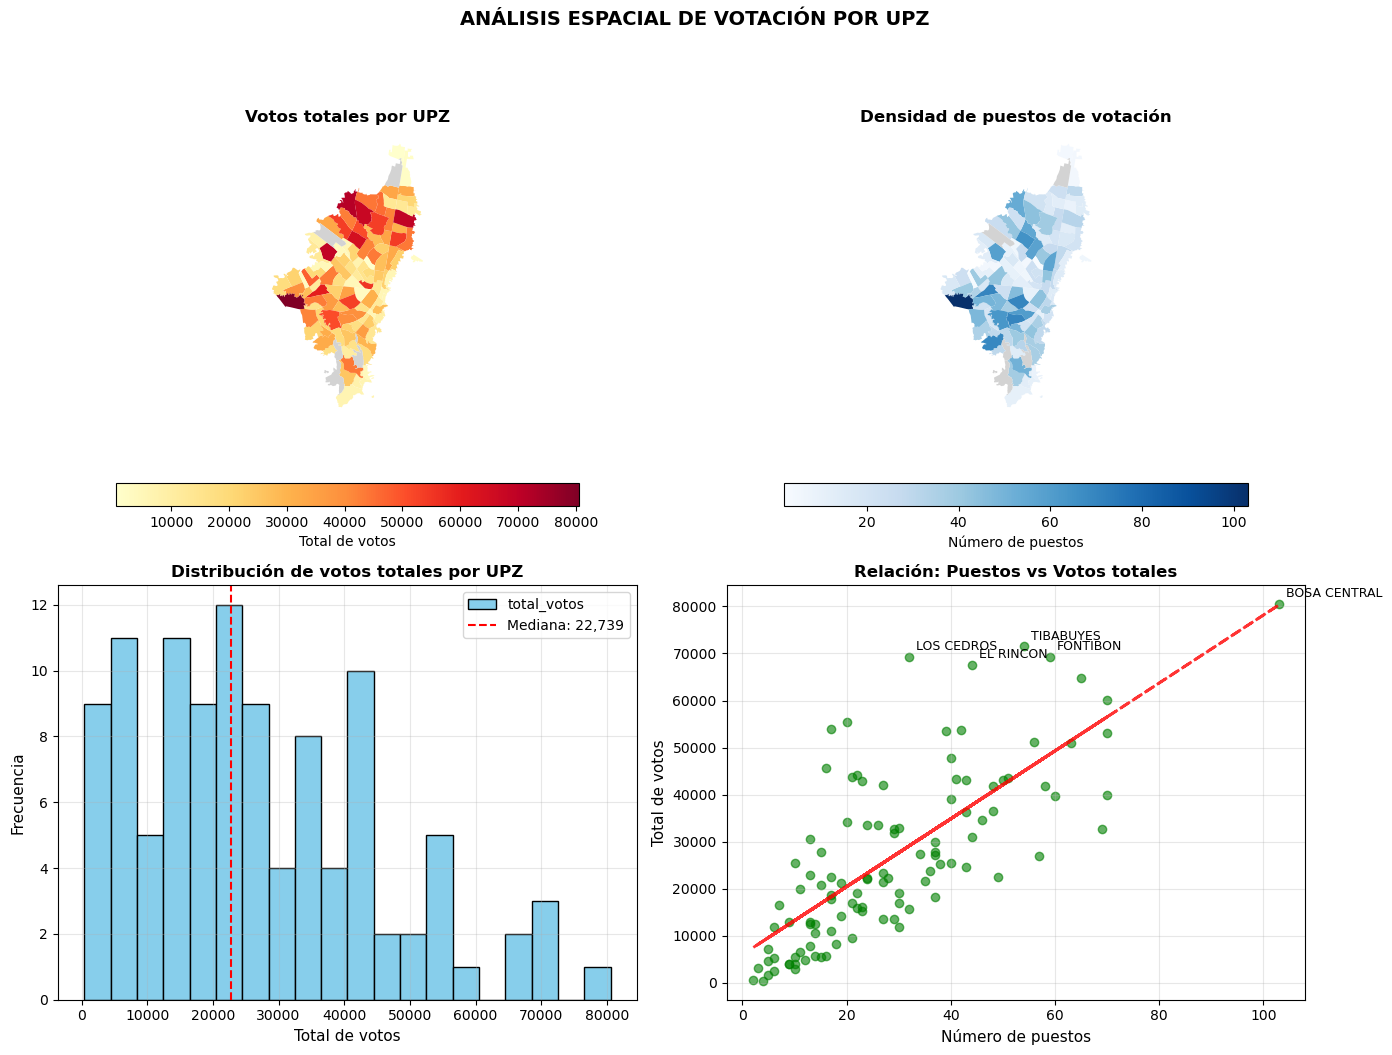


5. Análisis de concentración...
   • Coeficiente de Gini: 0.380
   • Interpretación: Baja concentración
   ✓ Curva de Lorenz guardada como 'curva_lorenz_gini.png'


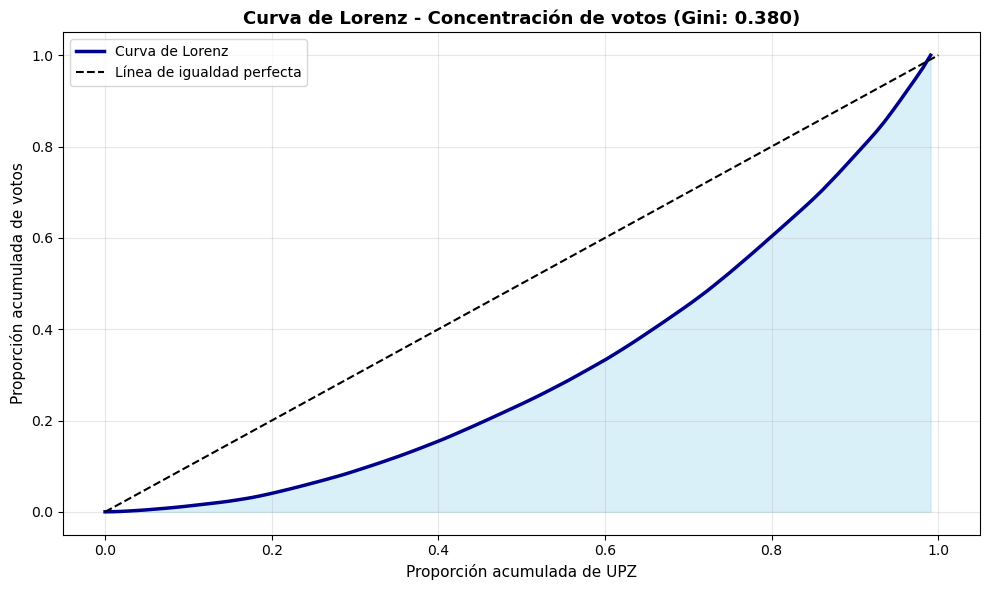


6. Guardando datos procesados...
   ✓ Datos guardados:
     - 'votacion_con_upz.csv' (datos de votación con UPZ)
     - 'upz_con_estadisticas.geojson' (UPZ con estadísticas)

BLOQUE 1 COMPLETADO ✓

RESUMEN EJECUTIVO:
• Total registros: 3,179
• UPZ con datos: 108
• Votos totales: 2,897,498
• Promedio votos por UPZ: 26,829
• Coeficiente de Gini: 0.380
• UPZ con más votos: BOSA CENTRAL


In [5]:
# ============================================================================
# CONFIGURACIÓN PARA VISUALIZACIÓN EN JUPYTER NOTEBOOK
# ============================================================================
# Configurar parámetros de visualización para Jupyter
plt.rcParams['figure.figsize'] = [14, 10]  # Tamaño óptimo para Jupyter
plt.rcParams['figure.autolayout'] = True   # Ajuste automático del layout
plt.rcParams['figure.dpi'] = 100           # Resolución adecuada para pantalla
plt.rcParams['font.size'] = 10             # Tamaño de fuente base

# ============================================================================
# BLOQUE 1: ANÁLISIS EXPLORATORIO ESPACIAL
# ============================================================================
print("=" * 60)
print("BLOQUE 1: ANÁLISIS EXPLORATORIO ESPACIAL")
print("=" * 60)

# 1. CARGAR DATOS UPZ
print("\n1. Cargando shapefile UPZ...")
upz_path = r"C:\Users\qluis\Documents\Concejo\Bases de datos\Geodata\upz-bogota"
upz_gdf = gpd.read_file(upz_path).to_crs('EPSG:4326')
print(f"   ✓ UPZ cargadas: {len(upz_gdf)} polígonos")

# 2. VERIFICAR ESTRUCTURA
print("\n2. Verificando estructura de datos...")
print(f"   Registros en df: {len(df)}")
print(f"   UPZ asignadas: {df['upz'].notna().sum()} ({df['upz'].isna().sum()} sin UPZ)")
print(f"   Rango de años: {df['año'].min()} - {df['año'].max()}")

# 3. ANÁLISIS ESTADÍSTICO POR UPZ
print("\n3. Análisis estadístico por UPZ...")

# Agrupar por UPZ
upz_stats = df.groupby('upz').agg(
    total_votos=pd.NamedAgg(column='votacion', aggfunc='sum'),
    puestos=pd.NamedAgg(column='votacion', aggfunc='count'),
    promedio_votos=pd.NamedAgg(column='votacion', aggfunc='mean'),
    desviacion_votos=pd.NamedAgg(column='votacion', aggfunc='std')
).round(2)

# Unir con geometría UPZ
upz_completo = upz_gdf[['nombre', 'geometry']].merge(
    upz_stats, 
    left_on='nombre', 
    right_index=True, 
    how='left'
)

# Estadísticas resumen
print(f"   • UPZ con datos: {upz_completo['total_votos'].notna().sum()}")
print(f"   • UPZ sin datos: {upz_completo['total_votos'].isna().sum()}")
print(f"   • Votos totales: {upz_completo['total_votos'].sum():,.0f}")
print(f"   • Puestos totales: {upz_completo['puestos'].sum():,.0f}")

# Top 10 UPZ por votos
print(f"\n   TOP 10 UPZ POR VOTOS:")
top10 = upz_completo.sort_values('total_votos', ascending=False).head(10)
for i, row in top10.iterrows():
    print(f"   {i+1:2d}. {row['nombre'][:30]:30} {row['total_votos']:>10,.0f}")

# 4. VISUALIZACIÓN ESPACIAL (PRIMERA FIGURA)
print("\n4. Generando visualizaciones...")

fig, axes = plt.subplots(2, 2)
fig.suptitle('ANÁLISIS ESPACIAL DE VOTACIÓN POR UPZ', fontsize=14, fontweight='bold', y=1.05)

# 4.1 Mapa coroplético de votos totales
ax1 = axes[0, 0]
upz_completo.plot(
    column='total_votos',
    cmap='YlOrRd',
    legend=True,
    ax=ax1,
    legend_kwds={'label': 'Total de votos', 'orientation': 'horizontal', 'shrink': 0.8},
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'}
)
ax1.set_title('Votos totales por UPZ', fontweight='bold', fontsize=12)
ax1.set_axis_off()

# 4.2 Mapa de densidad de puestos
ax2 = axes[0, 1]
upz_completo.plot(
    column='puestos',
    cmap='Blues',
    legend=True,
    ax=ax2,
    legend_kwds={'label': 'Número de puestos', 'orientation': 'horizontal', 'shrink': 0.8},
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'}
)
ax2.set_title('Densidad de puestos de votación', fontweight='bold', fontsize=12)
ax2.set_axis_off()

# 4.3 Histograma de distribución de votos por UPZ
ax3 = axes[1, 0]
upz_completo['total_votos'].dropna().plot.hist(
    bins=20,
    color='skyblue',
    edgecolor='black',
    ax=ax3
)
ax3.set_title('Distribución de votos totales por UPZ', fontweight='bold', fontsize=12)
ax3.set_xlabel('Total de votos', fontsize=11)
ax3.set_ylabel('Frecuencia', fontsize=11)
median_votes = upz_completo['total_votos'].median()
ax3.axvline(median_votes, color='red', linestyle='--', 
            label=f'Mediana: {median_votes:,.0f}')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# 4.4 Scatter plot: votos vs puestos
ax4 = axes[1, 1]
mask = upz_completo['total_votos'].notna() & upz_completo['puestos'].notna()
scatter = ax4.scatter(
    upz_completo.loc[mask, 'puestos'],
    upz_completo.loc[mask, 'total_votos'],
    alpha=0.6,
    color='green'
)

# Añadir etiquetas para top 5
top5 = upz_completo[mask].nlargest(5, 'total_votos')
for _, row in top5.iterrows():
    ax4.annotate(
        row['nombre'][:15],
        (row['puestos'], row['total_votos']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

# Línea de tendencia
z = np.polyfit(upz_completo.loc[mask, 'puestos'], 
              upz_completo.loc[mask, 'total_votos'], 1)
p = np.poly1d(z)
ax4.plot(upz_completo.loc[mask, 'puestos'], 
        p(upz_completo.loc[mask, 'puestos']), 
        "r--", alpha=0.8, linewidth=2)

ax4.set_title('Relación: Puestos vs Votos totales', fontweight='bold', fontsize=12)
ax4.set_xlabel('Número de puestos', fontsize=11)
ax4.set_ylabel('Total de votos', fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_espacial_upz.png', dpi=150, bbox_inches='tight')
print("   ✓ Gráficos guardados como 'analisis_espacial_upz.png'")

# Mostrar primera figura
plt.show()

# 5. ANÁLISIS DE CONCENTRACIÓN (SEGUNDA FIGURA)
print("\n5. Análisis de concentración...")

votos_series = upz_completo['total_votos'].dropna()
votos_sorted = np.sort(votos_series)
votos_cumsum = np.cumsum(votos_sorted)
votos_cumsum_norm = votos_cumsum / votos_cumsum[-1]

# Índice de Gini
n = len(votos_sorted)
indices = np.arange(1, n + 1)
gini = (np.sum((2 * indices - n - 1) * votos_sorted)) / (n * np.sum(votos_sorted))

print(f"   • Coeficiente de Gini: {gini:.3f}")
print(f"   • Interpretación: {'Alta concentración' if gini > 0.6 else 'Moderada concentración' if gini > 0.4 else 'Baja concentración'}")

# Curva de Lorenz (figura separada con tamaño ajustado)
fig_lorenz, ax_lorenz = plt.subplots(figsize=(10, 6))
ax_lorenz.plot(np.arange(n) / n, votos_cumsum_norm, label='Curva de Lorenz', 
               color='darkblue', linewidth=2.5)
ax_lorenz.plot([0, 1], [0, 1], 'k--', label='Línea de igualdad perfecta', linewidth=1.5)
ax_lorenz.fill_between(np.arange(n) / n, 0, votos_cumsum_norm, alpha=0.3, color='skyblue')
ax_lorenz.set_title(f'Curva de Lorenz - Concentración de votos (Gini: {gini:.3f})', 
                    fontweight='bold', fontsize=13)
ax_lorenz.set_xlabel('Proporción acumulada de UPZ', fontsize=11)
ax_lorenz.set_ylabel('Proporción acumulada de votos', fontsize=11)
ax_lorenz.legend(fontsize=10)
ax_lorenz.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curva_lorenz_gini.png', dpi=150, bbox_inches='tight')
print("   ✓ Curva de Lorenz guardada como 'curva_lorenz_gini.png'")

# Mostrar segunda figura
plt.show()

# 6. GUARDAR DATOS PROCESADOS
print("\n6. Guardando datos procesados...")
df.to_csv('votacion_con_upz.csv', index=False, encoding='utf-8')
upz_completo.to_file('upz_con_estadisticas.geojson', driver='GeoJSON')
print("   ✓ Datos guardados:")
print("     - 'votacion_con_upz.csv' (datos de votación con UPZ)")
print("     - 'upz_con_estadisticas.geojson' (UPZ con estadísticas)")

print("\n" + "=" * 60)
print("BLOQUE 1 COMPLETADO ✓")
print("=" * 60)

# RESUMEN EJECUTIVO
print("\nRESUMEN EJECUTIVO:")
print(f"• Total registros: {len(df):,}")
print(f"• UPZ con datos: {upz_completo['total_votos'].notna().sum()}")
print(f"• Votos totales: {upz_completo['total_votos'].sum():,.0f}")
print(f"• Promedio votos por UPZ: {upz_completo['total_votos'].mean():,.0f}")
print(f"• Coeficiente de Gini: {gini:.3f}")
print(f"• UPZ con más votos: {upz_completo.loc[upz_completo['total_votos'].idxmax(), 'nombre']}")

## HDBSCAN

CLUSTERING HDBSCAN - PREPARACIÓN DE DATOS
Clusters encontrados: 48
Puntos como ruido: 834 (26.3%)

ANÁLISIS ESTADÍSTICO DE CLUSTERS
✓ Figura estadística guardada como 'analisis_estadistico_clusters_optimizado.png'


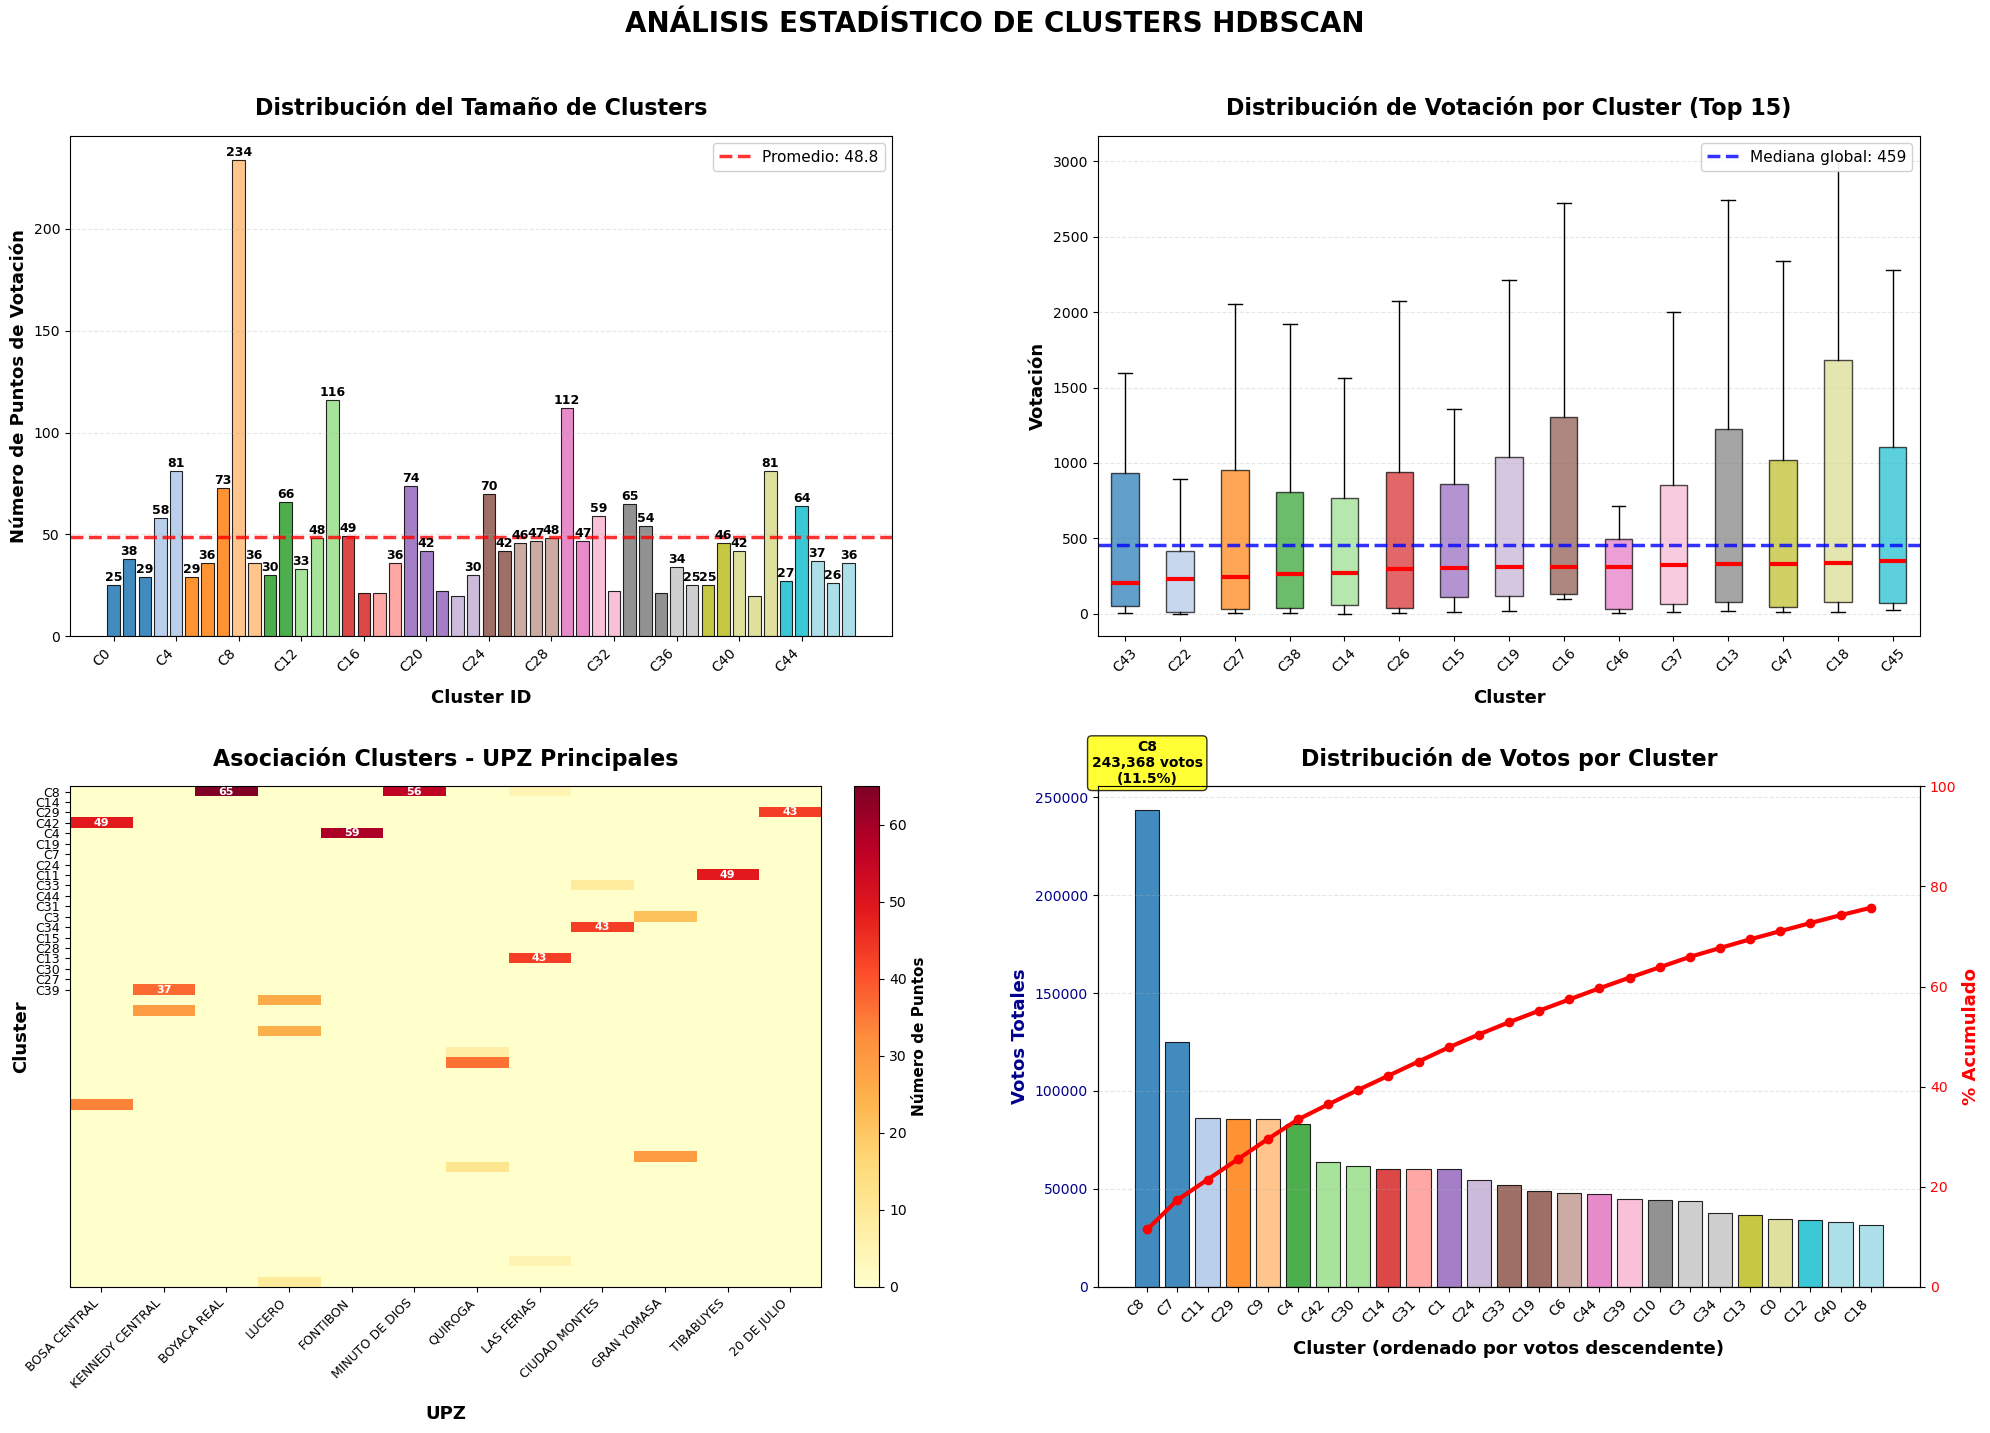


Generando mapa de clusters simplificado...
✓ Mapa de clusters guardado como 'mapa_clusters_simplificado.png'


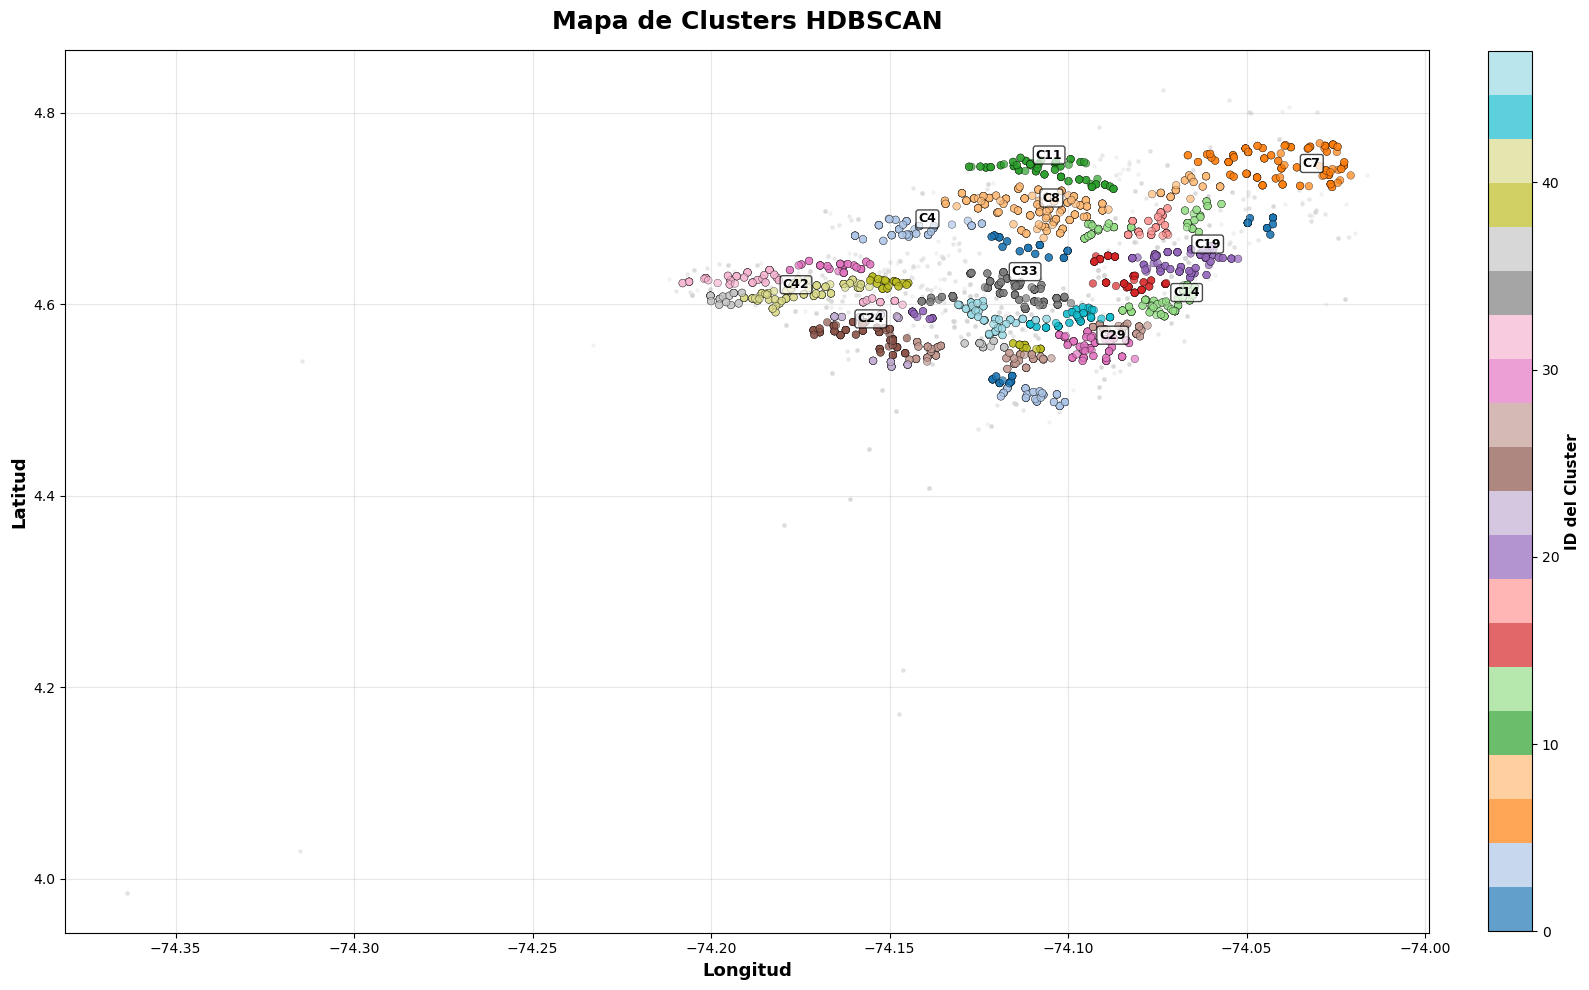


RESUMEN ESTADÍSTICO
Total clusters: 48
Puntos en clusters: 2,343
Votos totales en clusters: 2,120,889
Votos promedio por punto: 905.2

Concentración de votos (Índice de Gini): 0.366

PROCESO COMPLETADO EXITOSAMENTE


In [7]:
# ============================================================================
# 1. CLUSTERING HDBSCAN
# ============================================================================
print("=" * 60)
print("CLUSTERING HDBSCAN - PREPARACIÓN DE DATOS")
print("=" * 60)

# Limpieza y preparación
df_clean = df.dropna(subset=['latitud', 'longitud']).copy()
coords_rad = np.radians(df_clean[['latitud', 'longitud']].values)

# Parámetros del modelo
min_cluster_size = 20
min_samples = 5

# Modelo HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    metric='haversine',
    cluster_selection_method='eom',
    prediction_data=True
)

cluster_labels = clusterer.fit_predict(coords_rad)
df['hdbscan_cluster'] = np.nan
df.loc[df_clean.index, 'hdbscan_cluster'] = cluster_labels

# Estadísticas
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)
print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos como ruido: {n_noise} ({n_noise/len(df_clean)*100:.1f}%)")

# ============================================================================
# 2. ANÁLISIS ESTADÍSTICO MEJORADO
# ============================================================================
print("\n" + "=" * 60)
print("ANÁLISIS ESTADÍSTICO DE CLUSTERS")
print("=" * 60)

# Preparar datos
df_clustered = df[df['hdbscan_cluster'].notna()].copy()
df_clustered['hdbscan_cluster'] = df_clustered['hdbscan_cluster'].astype(int)
df_noise = df_clustered[df_clustered['hdbscan_cluster'] == -1]
df_clusters = df_clustered[df_clustered['hdbscan_cluster'] != -1]

if df_clusters.empty:
    print("⚠ No hay clusters válidos para visualizar")
else:
    # Configurar figura (2x2)
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('ANÁLISIS ESTADÍSTICO DE CLUSTERS HDBSCAN', 
                fontsize=20, fontweight='bold', y=1.02)

    # 2.1 Distribución de tamaño de clusters
    cluster_sizes = df_clusters['hdbscan_cluster'].value_counts().sort_index()
    n_clusters_display = len(cluster_sizes)
    
    # Gestión inteligente de etiquetas
    if n_clusters_display > 15:
        step = max(1, n_clusters_display // 10)
        xtick_positions = np.arange(0, n_clusters_display, step)
        xtick_labels = [f'C{cluster_sizes.index[i]}' for i in xtick_positions]
    else:
        xtick_positions = np.arange(n_clusters_display)
        xtick_labels = [f'C{idx}' for idx in cluster_sizes.index]
    
    colors = plt.cm.tab20(np.linspace(0, 1, n_clusters_display))
    bars = ax1.bar(np.arange(n_clusters_display), cluster_sizes.values,
                  color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
    
    ax1.set_title('Distribución del Tamaño de Clusters', fontsize=16, fontweight='bold', pad=15)
    ax1.set_xlabel('Cluster ID', fontsize=13, fontweight='bold', labelpad=10)
    ax1.set_ylabel('Número de Puntos de Votación', fontsize=13, fontweight='bold')
    ax1.set_xticks(xtick_positions)
    ax1.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    # Añadir valores solo a las barras significativas
    threshold = cluster_sizes.values.max() * 0.1
    for bar in bars:
        height = bar.get_height()
        if height > threshold:
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    avg_size = cluster_sizes.mean()
    ax1.axhline(y=avg_size, color='red', linestyle='--', linewidth=2.5,
                alpha=0.8, label=f'Promedio: {avg_size:.1f}')
    ax1.legend(loc='upper right', fontsize=11, framealpha=0.9)

    # 2.2 Boxplot de votación por cluster (limitado a 15 clusters para claridad)
    cluster_medians = df_clusters.groupby('hdbscan_cluster')['votacion'].median().sort_values()
    max_clusters_box = 15
    clusters_to_plot = cluster_medians.index[:max_clusters_box] if len(cluster_medians) > max_clusters_box else cluster_medians.index
    
    box_data, box_labels = [], []
    for cluster in clusters_to_plot:
        box_data.append(df_clusters[df_clusters['hdbscan_cluster'] == cluster]['votacion'].values)
        box_labels.append(f'C{cluster}')
    
    bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True, 
                    showfliers=False, medianprops=dict(color='red', linewidth=3))
    
    for i, box in enumerate(bp['boxes']):
        box.set_facecolor(plt.cm.tab20(i / len(box_data)))
        box.set_alpha(0.7)
        box.set_edgecolor('black')
    
    ax2.set_title('Distribución de Votación por Cluster (Top 15)', fontsize=16, fontweight='bold', pad=15)
    ax2.set_xlabel('Cluster', fontsize=13, fontweight='bold', labelpad=10)
    ax2.set_ylabel('Votación', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax2.tick_params(axis='x', rotation=45, labelsize=10)
    
    global_median = df_clusters['votacion'].median()
    ax2.axhline(y=global_median, color='blue', linestyle='--', linewidth=2.5,
                alpha=0.8, label=f'Mediana global: {global_median:.0f}')
    ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)

    # 2.3 Heatmap Clusters-UPZ (optimizado)
    if 'upz' in df_clusters.columns and not df_clusters['upz'].isna().all():
        top_upz = df_clusters['upz'].value_counts().head(12).index.tolist()
        if top_upz:
            contingency = pd.crosstab(df_clusters['hdbscan_cluster'], df_clusters['upz'])[top_upz]
            cluster_order = df_clusters['hdbscan_cluster'].value_counts().index
            contingency = contingency.reindex(cluster_order)
            
            # Acortar nombres de UPZ
            short_upz_names = [upz[:15] + '...' if len(upz) > 15 else upz for upz in top_upz]
            
            im = ax3.imshow(contingency.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')
            ax3.set_title('Asociación Clusters - UPZ Principales', fontsize=16, fontweight='bold', pad=15)
            ax3.set_xlabel('UPZ', fontsize=13, fontweight='bold', labelpad=10)
            ax3.set_ylabel('Cluster', fontsize=13, fontweight='bold')
            
            ax3.set_xticks(range(len(short_upz_names)))
            ax3.set_xticklabels(short_upz_names, rotation=45, ha='right', fontsize=9)
            
            y_tick_labels = [f'C{cluster}' for cluster in cluster_order[:20]]  # Limitar a 20 clusters en Y
            ax3.set_yticks(range(min(20, len(cluster_order))))
            ax3.set_yticklabels(y_tick_labels, fontsize=9)
            
            # Añadir valores en celdas importantes
            for i in range(min(20, len(cluster_order))):
                for j in range(len(top_upz)):
                    value = contingency.iloc[i, j]
                    if value > 0 and value >= contingency.values.max()/3:
                        text_color = 'black' if value < contingency.values.max()/2 else 'white'
                        ax3.text(j, i, str(int(value)), ha='center', va='center',
                                color=text_color, fontsize=8, fontweight='bold')
            
            plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04).set_label('Número de Puntos', fontsize=11, fontweight='bold')
        else:
            ax3.text(0.5, 0.5, 'Datos insuficientes\npara heatmap', ha='center', va='center', fontsize=14)
            ax3.set_title('Asociación Clusters - UPZ', fontsize=16, fontweight='bold')
    else:
        ax3.text(0.5, 0.5, 'Columna UPZ no disponible', ha='center', va='center', fontsize=14)
        ax3.set_title('Asociación Clusters - UPZ', fontsize=16, fontweight='bold')

    # 2.4 Distribución acumulada de votos
    cluster_votes = df_clusters.groupby('hdbscan_cluster')['votacion'].sum().sort_values(ascending=False)
    cumulative_votes = cluster_votes.cumsum() / cluster_votes.sum() * 100
    
    # Limitar a 25 clusters para visualización clara
    max_display = 25
    if len(cluster_votes) > max_display:
        display_clusters = cluster_votes.head(max_display)
        display_cumulative = cumulative_votes.head(max_display)
    else:
        display_clusters = cluster_votes
        display_cumulative = cumulative_votes
    
    n_display = len(display_clusters)
    colors_bar = plt.cm.tab20(np.linspace(0, 1, n_display))
    
    bars_votes = ax4.bar(range(n_display), display_clusters.values,
                        color=colors_bar, edgecolor='black', linewidth=0.8, alpha=0.85)
    
    ax4.set_title('Distribución de Votos por Cluster', fontsize=16, fontweight='bold', pad=15)
    ax4.set_xlabel('Cluster (ordenado por votos descendente)', fontsize=13, fontweight='bold', labelpad=10)
    ax4.set_ylabel('Votos Totales', fontsize=13, fontweight='bold', color='darkblue')
    ax4.tick_params(axis='y', labelcolor='darkblue')
    
    x_labels = [f'C{idx}' for idx in display_clusters.index]
    ax4.set_xticks(range(n_display))
    ax4.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)
    ax4.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    # Segundo eje Y para porcentaje acumulado
    ax4_twin = ax4.twinx()
    ax4_twin.plot(range(n_display), display_cumulative.values,
                 color='red', linewidth=3, marker='o', markersize=6)
    ax4_twin.set_ylabel('% Acumulado', fontsize=13, fontweight='bold', color='red')
    ax4_twin.tick_params(axis='y', labelcolor='red')
    ax4_twin.set_ylim(0, 100)
    
    # Añadir anotaciones clave
    if n_display > 0:
        first_votes = display_clusters.iloc[0]
        first_percent = display_cumulative.iloc[0]
        ax4.text(0, first_votes * 1.05, f'C{display_clusters.index[0]}\n{first_votes:,.0f} votos\n({first_percent:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.8))
    
    # Ajustes finales
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, wspace=0.25)
    plt.savefig('analisis_estadistico_clusters_optimizado.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("✓ Figura estadística guardada como 'analisis_estadistico_clusters_optimizado.png'")
    plt.show()

    # ============================================================================
    # 3. MAPA DE CLUSTERS SIMPLIFICADO (sin leyendas superpuestas)
    # ============================================================================
    print("\nGenerando mapa de clusters simplificado...")
    
    fig2, ax_map = plt.subplots(1, 1, figsize=(16, 10))
    
    # Separar datos
    valid_clusters = df[df['hdbscan_cluster'].notna() & (df['hdbscan_cluster'] != -1)].copy()
    noise_data = df[df['hdbscan_cluster'].isna() | (df['hdbscan_cluster'] == -1)]
    
    # Plot ruido
    if not noise_data.empty:
        ax_map.scatter(noise_data['longitud'], noise_data['latitud'], 
                      c='lightgray', alpha=0.2, s=5, label='Ruido')
    
    # Plot clusters usando color por cluster ID
    if not valid_clusters.empty:
        valid_clusters['hdbscan_cluster'] = valid_clusters['hdbscan_cluster'].astype(int)
        unique_clusters = sorted(valid_clusters['hdbscan_cluster'].unique())
        
        # Usar colormap continuo para muchos clusters
        cmap = plt.cm.tab20
        norm = plt.Normalize(vmin=0, vmax=len(unique_clusters)-1)
        
        scatter = ax_map.scatter(valid_clusters['longitud'], valid_clusters['latitud'],
                               c=valid_clusters['hdbscan_cluster'].map(lambda x: unique_clusters.index(x)),
                               cmap=cmap, norm=norm, alpha=0.7, s=30, edgecolors='black', linewidth=0.3)
        
        # Barra de color en lugar de leyenda
        cbar = plt.colorbar(scatter, ax=ax_map, fraction=0.03, pad=0.04)
        cbar.set_label('ID del Cluster', fontsize=11, fontweight='bold')
        
        # Anotar solo los clusters más grandes
        cluster_sizes_map = valid_clusters['hdbscan_cluster'].value_counts()
        large_clusters = cluster_sizes_map[cluster_sizes_map > cluster_sizes_map.median()].index
        
        for cluster in large_clusters[:10]:  # Limitar a 10 anotaciones
            cluster_points = valid_clusters[valid_clusters['hdbscan_cluster'] == cluster]
            center_lon, center_lat = cluster_points['longitud'].mean(), cluster_points['latitud'].mean()
            ax_map.annotate(f'C{cluster}', (center_lon, center_lat),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=9, fontweight='bold',
                           bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
    
    ax_map.set_title('Mapa de Clusters HDBSCAN', fontsize=18, fontweight='bold', pad=15)
    ax_map.set_xlabel('Longitud', fontsize=13, fontweight='bold')
    ax_map.set_ylabel('Latitud', fontsize=13, fontweight='bold')
    ax_map.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('mapa_clusters_simplificado.png', dpi=300, bbox_inches='tight')
    print("✓ Mapa de clusters guardado como 'mapa_clusters_simplificado.png'")
    plt.show()

    # ============================================================================
    # 4. RESUMEN ESTADÍSTICO
    # ============================================================================
    print("\n" + "=" * 60)
    print("RESUMEN ESTADÍSTICO")
    print("=" * 60)
    
    cluster_summary = df_clusters.groupby('hdbscan_cluster').agg(
        puntos=('votacion', 'count'),
        votos_totales=('votacion', 'sum'),
        votos_promedio=('votacion', 'mean'),
        votos_mediana=('votacion', 'median')
    ).round(2)
    
    total_votes = df_clusters['votacion'].sum()
    total_points = len(df_clusters)
    
    print(f"Total clusters: {len(cluster_summary)}")
    print(f"Puntos en clusters: {total_points:,}")
    print(f"Votos totales en clusters: {total_votes:,}")
    print(f"Votos promedio por punto: {total_votes/total_points:,.1f}")
    
    # Índice de Gini simplificado
    votes_series = cluster_summary['votos_totales'].values
    votes_sorted = np.sort(votes_series)
    n = len(votes_sorted)
    indices = np.arange(1, n + 1)
    gini = (np.sum((2 * indices - n - 1) * votes_sorted)) / (n * np.sum(votes_sorted))
    
    print(f"\nConcentración de votos (Índice de Gini): {gini:.3f}")
    
    # Guardar resultados
    df.to_csv('votacion_con_clusters_unificado.csv', index=False, encoding='utf-8')
    cluster_summary.to_csv('estadisticas_clusters_unificado.csv', encoding='utf-8')
    
    with open('resumen_analisis_clusters.txt', 'w', encoding='utf-8') as f:
        f.write("RESUMEN ANÁLISIS CLUSTERS HDBSCAN\n")
        f.write("="*50 + "\n")
        f.write(f"Parámetros: min_cluster_size={min_cluster_size}, min_samples={min_samples}\n")
        f.write(f"Clusters encontrados: {n_clusters}\n")
        f.write(f"Puntos como ruido: {n_noise} ({n_noise/len(df_clean)*100:.1f}%)\n")
        f.write(f"Concentración (Gini): {gini:.3f}\n\n")
        f.write("Top 5 clusters por votos:\n")
        top5 = cluster_summary.sort_values('votos_totales', ascending=False).head(5)
        for idx, row in top5.iterrows():
            f.write(f"  Cluster {idx}: {row['votos_totales']:,.0f} votos, {row['puntos']} puntos\n")

print("\n" + "=" * 60)
print("PROCESO COMPLETADO EXITOSAMENTE")
print("=" * 60)

## CONSULTAS SQL

In [2]:
## Crea la base de datos (en caso que no exista)
con = sqlite3.connect('electoralgalan.db')
cur = con.cursor()

In [10]:
df.to_sql('completo', con, if_exists='replace', index=False)

3179

In [3]:
## Crea el motor de conexion con la base de datos
engine = create_engine('sqlite:///electoralgalan.db')

In [22]:
query1 = """
SELECT 
    SUM ("votacion") as votos, 
    lugar, 
    localidad
FROM completo
GROUP BY lugar
ORDER BY votos DESC
"""
df1 = pd.read_sql(query1, engine)
print("Los puestos de votación con mayor cantidad de votos son:")
df1.head(20)

Los puestos de votación con mayor cantidad de votos son:


,votos,lugar,localidad
0,35836,PUESTO CENSO(FERIA EXPOSICION),NACIONAL
1,28829,CENTRO COMERCIAL UNICENTRO,USAQUEN
2,18645,LOS CEDRITOS,USAQUEN
3,15502,CENTRO COMERCIAL CEDRITOS 151,USAQUEN
4,14606,PARQUE FUNDACIONAL DE SUBA,SUBA
5,14543,FONTIBON,FONTIBON
6,13966,USAQUÉN,USAQUEN
7,12670,SERVITA,USAQUEN
8,12358,CENTRO COMERCIAL BULEVAR NIZA,SUBA
9,11938,CIUDADELA COLSUBSIDIO,ENGATIVA


In [23]:
query2 = """
SELECT 
    SUM ("votacion") as votos, 
    localidad
FROM completo
GROUP BY localidad
ORDER BY votos DESC
"""
df2 = pd.read_sql(query2, engine)
df2.head(20)

,votos,localidad
0,445640,SUBA
1,335830,KENNEDY
2,318990,ENGATIVA
3,288316,USAQUEN
4,181947,BOSA
5,174172,CIUDAD BOLIVAR
6,161184,FONTIBON
7,122115,SAN CRISTOBAL
8,120547,PUENTE ARANDA
9,118245,RAFAEL URIBE URIBE


In [1]:
query3 = """
SELECT SUM ("votacion") as votos, upz, localidad
FROM completo
GROUP BY upz
ORDER BY votos DESC
"""
df3 = pd.read_sql(query3, engine)
df3.head(40)

NameError: name 'pd' is not defined

In [14]:
query3 = """
SELECT 
    upz,
    COUNT(DISTINCT lugar) AS numero_puestos,
    localidad
FROM completo
GROUP BY upz
ORDER BY numero_puestos DESC;
"""
df3 = pd.read_sql(query3, engine)
df3.head(10)

,upz,numero_puestos,localidad
0,TIBABUYES,36,USAQUEN
1,BOSA CENTRAL,36,BOSA
2,KENNEDY CENTRAL,30,BOSA
3,EL RINCON,30,SUBA
4,None,28,SANTA FE
5,VENECIA,25,TUNJUELITO
6,CASTILLA,24,KENNEDY
7,CIUDAD MONTES,23,LOS MARTIRES
8,QUIROGA,19,RAFAEL URIBE URIBE
9,LUCERO,19,CIUDAD BOLIVAR


In [18]:
query3 = """
SELECT 
    upz,
    localidad,
    SUM (votacion) as votos
FROM completo
GROUP BY upz
ORDER BY votos DESC
"""
df3 = pd.read_sql(query3, engine)
df3.head(50)

,upz,localidad,votos
0,BOSA CENTRAL,BOSA,80538
1,TIBABUYES,USAQUEN,76552
2,LOS CEDROS,USAQUEN,69289
3,FONTIBON,FONTIBON,69247
4,EL RINCON,SUBA,67634
5,BOYACA REAL,ENGATIVA,64821
6,KENNEDY CENTRAL,BOSA,60125
7,QUINTA PAREDES,NACIONAL,55399
8,SANTA BARBARA,USAQUEN,53987
9,GARCES NAVAS,ENGATIVA,53687


In [14]:
query3 = """
SELECT 
    DISTINCT lugar
FROM completo
WHERE lugar LIKE '%NIZA%'
"""
df3 = pd.read_sql(query3, engine)
df3.head(50)

,lugar
0,NIZA IX
1,NIZA LEY
2,NIZA NORTE
3,NIZA VIII
4,CENTRO COMERCIAL BULEVAR NIZA
5,CHUNIZA


In [9]:
query4 = """
SELECT localidad,
       lugar,
       total_votos
FROM (
    SELECT localidad,
           lugar,
           SUM(votacion) AS total_votos,
           ROW_NUMBER() OVER (
               PARTITION BY localidad
               ORDER BY SUM(votacion) DESC
           ) AS posicion
    FROM completo
    GROUP BY localidad, lugar
) AS sub
WHERE posicion <= 2
ORDER BY localidad, posicion;
"""
df4 = pd.read_sql(query4, engine)
df4.head(50)






,localidad,lugar,total_votos
0,ANTONIO NARINO,RESTREPO A,6711
1,ANTONIO NARINO,CIUDAD JARDIN,6262
2,BARRIOS UNIDOS,METROPOLIS,7402
3,BARRIOS UNIDOS,POPULAR MODELO,7280
4,BOSA,LA LIBERTAD,10888
5,BOSA,BOSA,9424
6,CHAPINERO,ANTIGUO COUNTRY PLAZOLETA CARULLA,9054
7,CHAPINERO,CHICO NORTE,8018
8,CIUDAD BOLIVAR,CHICO LICEO FRANCES LOUIS PASTEUR,11183
9,CIUDAD BOLIVAR,ISMAEL PERDOMO,9446


In [11]:
## Cerrar conexiones
con.close()
engine.dispose()

## Mapas interactivos

In [9]:
# ============================================================================
# MAPA INTERACTIVO DE VOTACIÓN - VERSIÓN INTEGRADA Y MEJORADA
# ============================================================================
print("=" * 60)
print("MAPA INTERACTIVO DE VOTACIÓN - VERSIÓN INTEGRADA")
print("=" * 60)

# 1. LIMPIAR Y AGREGAR DATOS
print("\n1. Limpiando y agregando datos por punto de votación...")

df_clean = df.dropna(subset=['latitud', 'longitud', 'votacion']).copy()

# Crear clave única para cada punto
df_clean['punto_key'] = df_clean.apply(
    lambda row: f"{row['lugar']}_{row['latitud']:.5f}_{row['longitud']:.5f}", 
    axis=1
)

# Agrupar por punto único y sumar votos de todos los años
df_agregado = df_clean.groupby(['punto_key', 'lugar', 'latitud', 'longitud', 'upz', 'localidad']).agg({
    'votacion': 'sum',
    'año': 'count'
}).reset_index()

df_agregado = df_agregado.rename(columns={
    'votacion': 'votacion_total',
    'año': 'num_años'
})

# Verificar si existe columna hdbscan_cluster
has_hdbscan = False
if 'hdbscan_cluster' in df_clean.columns:
    cluster_moda = df_clean.groupby('punto_key')['hdbscan_cluster'].apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    ).reset_index()
    cluster_moda.columns = ['punto_key', 'hdbscan_cluster']
    
    df_agregado = df_agregado.merge(cluster_moda, on='punto_key', how='left')
    df_clustered = df_agregado[df_agregado['hdbscan_cluster'].notna()].copy()
    df_clustered['hdbscan_cluster'] = df_clustered['hdbscan_cluster'].astype(int)
    df_clustered = df_clustered[df_clustered['hdbscan_cluster'] != -1]
    
    if len(df_clustered) > 0:
        has_hdbscan = True
        print(f"   • Puntos con cluster HDBSCAN válido: {len(df_clustered)}")

print(f"   • Puntos únicos: {len(df_agregado)}")
print(f"   • Votos totales: {df_agregado['votacion_total'].sum():,.0f}")

# 2. CARGAR DATOS UPZ
print("\n2. Cargando datos UPZ...")

try:
    upz_path = r"C:\Users\qluis\Documents\Concejo\Bases de datos\Geodata\upz-bogota"
    upz_gdf = gpd.read_file(upz_path).to_crs('EPSG:4326')
    
    upz_stats = df_agregado.groupby('upz').agg(
        total_votos=('votacion_total', 'sum'),
        puestos=('votacion_total', 'count'),
        votos_promedio=('votacion_total', 'mean')
    ).round(2)
    
    upz_gdf = upz_gdf.merge(upz_stats, left_on='nombre', right_index=True, how='left')
    upz_disponible = True
    print(f"   ✓ {len(upz_gdf)} UPZ cargadas")
except Exception as e:
    upz_disponible = False
    print(f"   ⚠ No se pudo cargar UPZ: {e}")

# 3. CREAR MAPA BASE
print("\n3. Configurando mapa base...")

center_lat = df_agregado['latitud'].mean()
center_lon = df_agregado['longitud'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles='OpenStreetMap',
    control_scale=True,
    prefer_canvas=True
)

print("   ✓ Mapa base creado")

# 4. CAPA 1: MAPA DE CALOR (VERSIÓN OPTIMIZADA)
print("\n4. Creando mapa de calor optimizado...")

heat_data = [[row['latitud'], row['longitud'], row['votacion_total']] 
             for _, row in df_agregado.iterrows()]

heatmap_fg = folium.FeatureGroup(name='Mapa de Calor - Votación Total', show=True)

HeatMap(
    heat_data,
    min_opacity=0.3,
    max_opacity=0.85,
    max_zoom=18,
    radius=15,
    blur=6,
    gradient={
        0.0: '#0000FF',
        0.4: '#00FFFF',
        0.6: '#00FF00',
        0.8: '#FFFF00',
        1.0: '#FF0000'
    }
).add_to(heatmap_fg)

heatmap_fg.add_to(m)
print(f"   ✓ Mapa de calor creado ({len(heat_data)} puntos)")

# 5. CAPA 2: CLUSTERS HDBSCAN
print("\n5. Creando clusters HDBSCAN...")

cluster_colors = [
    '#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF',
    '#00FFFF', '#FF6B6B', '#4ECDC4', '#FFD166', '#06D6A0',
    '#118AB2', '#073B4C', '#EF476F', '#1B998B', '#2D3047',
    '#FF9A00', '#9D4EDD', '#3A86FF', '#FB5607', '#8338EC'
]

if has_hdbscan and not df_clustered.empty:
    cluster_stats = df_clustered.groupby('hdbscan_cluster').agg(
        total_votos=('votacion_total', 'sum'),
        num_puntos=('votacion_total', 'count'),
        centro_lat=('latitud', 'mean'),
        centro_lon=('longitud', 'mean')
    )
    
    cluster_stats = cluster_stats[cluster_stats['num_puntos'] >= 2]
    
    hdbscan_fg = folium.FeatureGroup(name='Clusters HDBSCAN', show=False)
    
    for cluster_id, stats in cluster_stats.iterrows():
        cluster_points = df_clustered[df_clustered['hdbscan_cluster'] == cluster_id]
        
        if len(cluster_points) == 0:
            continue
        
        color_idx = int(cluster_id) % len(cluster_colors)
        cluster_color = cluster_colors[color_idx]
        
        votos_formateados = f"{stats['total_votos']:,.0f}"
        
        icon_create_function = f"""
        function(cluster) {{
            return L.divIcon({{
                html: `<div style="background-color: {cluster_color}; 
                       color: white; 
                       border-radius: 50%; 
                       width: 45px; 
                       height: 45px; 
                       display: flex; 
                       align-items: center; 
                       justify-content: center; 
                       font-weight: bold; 
                       border: 3px solid white; 
                       box-shadow: 3px 3px 8px rgba(0,0,0,0.5);
                       font-size: 12px;">
                       <span>{votos_formateados}</span>
                       </div>`,
                className: 'marker-cluster',
                iconSize: L.point(45, 45)
            }});
        }}
        """
        
        cluster_mc = MarkerCluster(
            name=f'Cluster {cluster_id}',
            options={
                'showCoverageOnHover': False,
                'zoomToBoundsOnClick': True,
                'spiderfyOnMaxZoom': True,
                'disableClusteringAtZoom': 15
            },
            icon_create_function=icon_create_function
        )
        
        for _, point in cluster_points.iterrows():
            if pd.isna(point['latitud']) or pd.isna(point['longitud']):
                continue
            
            lugar_nombre = str(point['lugar']) if pd.notna(point['lugar']) and point['lugar'] != '' else 'Sin nombre'
            
            popup_html = f"""
            <div style="font-family: Arial; min-width: 280px;">
                <h4 style="margin: 5px 0; color: {cluster_color}">{lugar_nombre}</h4>
                <hr style="margin: 5px 0;">
                <p style="margin: 3px 0;"><b>Votos totales:</b> {point['votacion_total']:,.0f}</p>
                <p style="margin: 3px 0;"><b>Años registrados:</b> {point['num_años']}</p>
                <p style="margin: 3px 0;"><b>Cluster:</b> {cluster_id}</p>
                <p style="margin: 3px 0;"><b>UPZ:</b> {point['upz'] if pd.notna(point['upz']) else 'N/A'}</p>
                <p style="margin: 3px 0;"><b>Localidad:</b> {point['localidad'] if pd.notna(point['localidad']) else 'N/A'}</p>
            </div>
            """
            
            size_factor = min(5 + (point['votacion_total'] / df_clustered['votacion_total'].max()) * 20, 25)
            
            folium.CircleMarker(
                location=[point['latitud'], point['longitud']],
                radius=size_factor,
                popup=folium.Popup(popup_html, max_width=300),
                color=cluster_color,
                fill=True,
                fill_color=cluster_color,
                fill_opacity=0.7,
                weight=1.5,
                tooltip=f"{lugar_nombre}: {point['votacion_total']:,.0f} votos (Cluster {cluster_id})"
            ).add_to(cluster_mc)
        
        if not pd.isna(stats['centro_lat']) and not pd.isna(stats['centro_lon']):
            center_popup = f"""
            <div style="font-family: Arial; min-width: 300px; padding: 10px;">
                <h4 style="color: {cluster_color}">Cluster {cluster_id}</h4>
                <hr style="margin: 5px 0;">
                <p><b>Total votos:</b> {stats['total_votos']:,.0f}</p>
                <p><b>Puestos:</b> {int(stats['num_puntos'])}</p>
                <p><b>Promedio:</b> {(stats['total_votos']/stats['num_puntos']):,.0f}</p>
            </div>
            """
            
            folium.Marker(
                location=[stats['centro_lat'], stats['centro_lon']],
                popup=folium.Popup(center_popup, max_width=300),
                icon=folium.Icon(color='gray', icon='star', prefix='fa'),
                tooltip=f"Cluster {cluster_id} - {stats['total_votos']:,.0f} votos"
            ).add_to(cluster_mc)
        
        cluster_mc.add_to(hdbscan_fg)
    
    hdbscan_fg.add_to(m)
    print(f"   ✓ {len(cluster_stats)} clusters HDBSCAN creados")
else:
    print("   ⚠ Clusters HDBSCAN no disponibles")

# 6. CAPA 3: PUNTOS INDIVIDUALES
print("\n6. Creando puntos de votación individuales...")

puntos_fg = folium.FeatureGroup(name='Puntos de Votación', show=False)
puntos_añadidos = 0

for _, punto in df_agregado.iterrows():
    if pd.isna(punto['latitud']) or pd.isna(punto['longitud']):
        continue
    
    lugar_nombre = str(punto['lugar']) if pd.notna(punto['lugar']) and punto['lugar'] != '' else 'Sin nombre'
    
    popup_html = f"""
    <div style="font-family: Arial; min-width: 280px;">
        <h4 style="margin: 5px 0;">{lugar_nombre}</h4>
        <hr style="margin: 5px 0;">
        <p style="margin: 3px 0;"><b>Votos totales:</b> {punto['votacion_total']:,.0f}</p>
        <p style="margin: 3px 0;"><b>Años registrados:</b> {punto['num_años']}</p>
        <p style="margin: 3px 0;"><b>UPZ:</b> {punto['upz'] if pd.notna(punto['upz']) else 'N/A'}</p>
        <p style="margin: 3px 0;"><b>Localidad:</b> {punto['localidad'] if pd.notna(punto['localidad']) else 'N/A'}</p>
    </div>
    """
    
    if df_agregado['votacion_total'].max() > 0:
        votacion_q = punto['votacion_total'] / df_agregado['votacion_total'].max()
    else:
        votacion_q = 0
    
    if votacion_q > 0.75:
        color, fill_color = '#FF0000', '#FF3333'
    elif votacion_q > 0.5:
        color, fill_color = '#FF9900', '#FFB366'
    elif votacion_q > 0.25:
        color, fill_color = '#00AA00', '#33CC33'
    else:
        color, fill_color = '#0066CC', '#3399FF'
    
    radius = 4 + (votacion_q * 8)
    
    folium.CircleMarker(
        location=[punto['latitud'], punto['longitud']],
        radius=radius,
        popup=folium.Popup(popup_html, max_width=300),
        color=color,
        fill=True,
        fill_color=fill_color,
        fill_opacity=0.7,
        weight=1.5,
        tooltip=f"{lugar_nombre}: {punto['votacion_total']:,.0f} votos"
    ).add_to(puntos_fg)
    
    puntos_añadidos += 1

puntos_fg.add_to(m)
print(f"   ✓ {puntos_añadidos} puntos individuales añadidos")

# 7. CAPA 4: VOTACIÓN POR UPZ
print("\n7. Creando capa de votación por UPZ...")

if upz_disponible:
    def get_upz_color(total_votos, max_votos):
        if pd.isna(total_votos) or max_votos == 0 or total_votos <= 0:
            return '#F0F0F0'
        
        normalized = total_votos / max_votos
        
        if normalized > 0.9:
            return '#440154'
        elif normalized > 0.7:
            return '#31688E'
        elif normalized > 0.5:
            return '#21918C'
        elif normalized > 0.3:
            return '#35B779'
        elif normalized > 0.15:
            return '#8FD744'
        elif normalized > 0.05:
            return '#FDE725'
        else:
            return '#F0F0F0'
    
    max_votos_upz = upz_gdf['total_votos'].max() if upz_gdf['total_votos'].max() > 0 else 1
    
    def style_function_upz(feature):
        return {
            'fillColor': get_upz_color(feature['properties'].get('total_votos'), max_votos_upz),
            'color': '#333333',
            'weight': 1.8,
            'dashArray': '2',
            'fillOpacity': 0.7
        }
    
    def highlight_function_upz(feature):
        return {
            'weight': 3,
            'color': '#000000',
            'dashArray': '',
            'fillOpacity': 0.9
        }
    
    upz_fg = folium.FeatureGroup(name='Votación por UPZ', show=False)
    
    upz_layer = folium.GeoJson(
        upz_gdf.__geo_interface__,
        name='UPZ',
        style_function=style_function_upz,
        highlight_function=highlight_function_upz,
        tooltip=folium.GeoJsonTooltip(
            fields=['nombre', 'total_votos', 'puestos', 'votos_promedio'],
            aliases=['UPZ:', 'Votos totales:', 'Puestos:', 'Promedio:'],
            localize=True,
            sticky=True,
            style="background-color: white; border: 2px solid black; border-radius: 3px; padding: 8px;"
        )
    )
    
    upz_layer.add_to(upz_fg)
    upz_fg.add_to(m)
    print(f"   ✓ {len(upz_gdf)} UPZ añadidas")
else:
    print("   ⚠ Capa UPZ no disponible")

# 8. AÑADIR CONTROLES
print("\n8. Añadiendo controles...")

folium.TileLayer('CartoDB dark_matter', name='Modo Oscuro').add_to(m)
folium.TileLayer('CartoDB positron', name='Modo Claro').add_to(m)

folium.LayerControl(position='topright', collapsed=True, autoZIndex=True).add_to(m)
folium.plugins.Fullscreen(position='topright').add_to(m)
folium.plugins.MiniMap(position='bottomright', width=150, height=150).add_to(m)

print("   ✓ Controles añadidos")

# 9. GUARDAR MAPA
print("\n9. Guardando mapa...")

output_path = 'mapa_votacion_integrado.html'
m.save(output_path)

print(f"\n✓ Mapa guardado: '{output_path}'")
print("\n" + "=" * 60)
print("RESUMEN DEL MAPA:")
print("=" * 60)
print(f"• Puntos de votación: {len(df_agregado):,}")
print(f"• Votos totales: {df_agregado['votacion_total'].sum():,.0f}")
print("\nCapas disponibles:")
print("1. Mapa de Calor (activa por defecto)")
print("2. Clusters HDBSCAN" + (" ✓" if has_hdbscan else " ✗"))
print("3. Puntos Individuales")
print("4. Votación por UPZ" + (" ✓" if upz_disponible else " ✗"))
print("=" * 60)

MAPA INTERACTIVO DE VOTACIÓN - VERSIÓN INTEGRADA

1. Limpiando y agregando datos por punto de votación...
   • Puntos con cluster HDBSCAN válido: 836
   • Puntos únicos: 1136
   • Votos totales: 2,893,409

2. Cargando datos UPZ...
   ✓ 114 UPZ cargadas

3. Configurando mapa base...
   ✓ Mapa base creado

4. Creando mapa de calor optimizado...
   ✓ Mapa de calor creado (1136 puntos)

5. Creando clusters HDBSCAN...
   ✓ 48 clusters HDBSCAN creados

6. Creando puntos de votación individuales...
   ✓ 1136 puntos individuales añadidos

7. Creando capa de votación por UPZ...
   ✓ 114 UPZ añadidas

8. Añadiendo controles...
   ✓ Controles añadidos

9. Guardando mapa...

✓ Mapa guardado: 'mapa_votacion_integrado.html'

RESUMEN DEL MAPA:
• Puntos de votación: 1,136
• Votos totales: 2,893,409

Capas disponibles:
1. Mapa de Calor (activa por defecto)
2. Clusters HDBSCAN ✓
3. Puntos Individuales
4. Votación por UPZ ✓
